In [7]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
from datetime import date

In [21]:
BASE_URL = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1"

def awdb_get(endpoint, **params):
    """GET request to the AWDB REST API, returns parsed JSON."""
    clean_params = {
        k: (str(v).lower() if isinstance(v, bool) else v)
        for k, v in params.items() if v is not None
    }
    url = f"{BASE_URL}/{endpoint}"
    resp = requests.get(url, params=clean_params, timeout=30)
    resp.raise_for_status()
    return resp.json()

print("Ready. Base URL:", BASE_URL)

Ready. Base URL: https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1


In [22]:
def build_triplet_pattern(state_codes=None, network_codes=None):
    """
    Build a comma-separated wildcard stationTriplets pattern, e.g. '*:CO:SNTL'.
    Each of state_codes/network_codes can be a single code, a list, or None (= wildcard '*').
    """
    states = state_codes if isinstance(state_codes, list) else ([state_codes] if state_codes else ["*"])
    networks = network_codes if isinstance(network_codes, list) else ([network_codes] if network_codes else ["*"])
    return ",".join(f"*:{s}:{n}" for s in states for n in networks)

def find_stations(state_codes=None, network_codes="SNTL", elements=None, active_only=True, **extra):
    """
    Search for stations by state/network (via wildcard triplet pattern) and, optionally,
    only stations that report a given element.

    e.g. find_stations(state_codes="CO")                    # all CO SNOTEL stations
         find_stations(state_codes=["CO", "UT"])             # multiple states
         find_stations(state_codes="CO", elements="WTEQ")    # only ones reporting SWE
    """
    params = {
        "stationTriplets": build_triplet_pattern(state_codes, network_codes),
        "activeOnly": active_only,
        "returnStationElements": True,
    }
    if elements:
        params["elements"] = ",".join(elements) if isinstance(elements, (list, tuple)) else elements
    params.update(extra)

    data = awdb_get("stations", **params)
    return pd.json_normalize(data)

def station_has_element(row, elem_code):
    elems = row.get("stationElements", [])
    return any(e.get("elementCode") == elem_code for e in elems)

co_stations = find_stations(state_codes="CO", elements="WTEQ")
print(f"{len(co_stations)} Colorado SNOTEL stations report WTEQ")
co_stations[["stationTriplet", "name", "elevation", "latitude", "longitude"]].head(10)

118 Colorado SNOTEL stations report WTEQ


,stationTriplet,name,elevation,latitude,longitude
0,1344:CO:SNTL,Alta Lakes,11290.0,37.88929,-107.84484
1,303:CO:SNTL,Apishapa,10000.0,37.33067,-105.06766
2,1030:CO:SNTL,Arapaho Ridge,10960.0,40.35098,-106.38141
3,322:CO:SNTL,Bear Lake,9490.0,40.31176,-105.64670
4,1061:CO:SNTL,Bear River,9100.0,40.06152,-107.00948
5,327:CO:SNTL,Beartown,11580.0,37.71433,-107.51240
6,1041:CO:SNTL,Beaver Ck Village,8530.0,39.59871,-106.51113
7,335:CO:SNTL,Berthoud Summit,11300.0,39.80364,-105.77786
8,345:CO:SNTL,Bison Lake,10950.0,39.76458,-107.35628
9,1185:CO:SNTL,Black Mesa,11580.0,37.78968,-108.18376


In [23]:
example_triplet = co_stations.iloc[0]["stationTriplet"] if len(co_stations) else "335:CO:SNTL"
print("Using station:", example_triplet, "-", co_stations.iloc[0]["name"] if len(co_stations) else "")

Using station: 1344:CO:SNTL - Alta Lakes


In [24]:
def get_snowpack_data(station_triplets, elements=("WTEQ", "SNWD"),
                       begin_date="2024-10-01", end_date=None, duration="DAILY"):
    """
    station_triplets : str or list[str]   e.g. "335:CO:SNTL"
    elements         : str or list[str]   e.g. ["WTEQ", "SNWD"]
    duration         : "DAILY", "HOURLY", "SEMIMONTHLY", "MONTHLY", "CALENDAR_YEAR", "WATER_YEAR"
    """
    if end_date is None:
        end_date = date.today().isoformat()
    if isinstance(station_triplets, (list, tuple)):
        station_triplets = ",".join(station_triplets)
    if isinstance(elements, (list, tuple)):
        elements = ",".join(elements)

    raw = awdb_get(
        "data",
        stationTriplets=station_triplets,
        elements=elements,
        duration=duration,
        beginDate=begin_date,
        endDate=end_date,
    )

    rows = []
    for station in raw:
        triplet = station.get("stationTriplet")
        for elem in station.get("data", []):
            code_ = elem.get("stationElement", {}).get("elementCode")
            for point in elem.get("values", []):
                rows.append({
                    "stationTriplet": triplet,
                    "element": code_,
                    "date": point.get("date"),
                    "value": point.get("value"),
                })

    df = pd.DataFrame(rows)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
    return df

swe_df = get_snowpack_data(
    station_triplets=example_triplet,
    elements=["WTEQ", "SNWD"],
    begin_date="2024-10-01",
)
print(f"{len(swe_df)} rows returned")
swe_df.head()

724 rows returned


,stationTriplet,element,date,value
0,1344:CO:SNTL,SNWD,2025-09-25,0.0
1,1344:CO:SNTL,SNWD,2025-09-26,0.0
2,1344:CO:SNTL,SNWD,2025-09-27,0.0
3,1344:CO:SNTL,SNWD,2025-09-28,0.0
4,1344:CO:SNTL,SNWD,2025-09-29,0.0


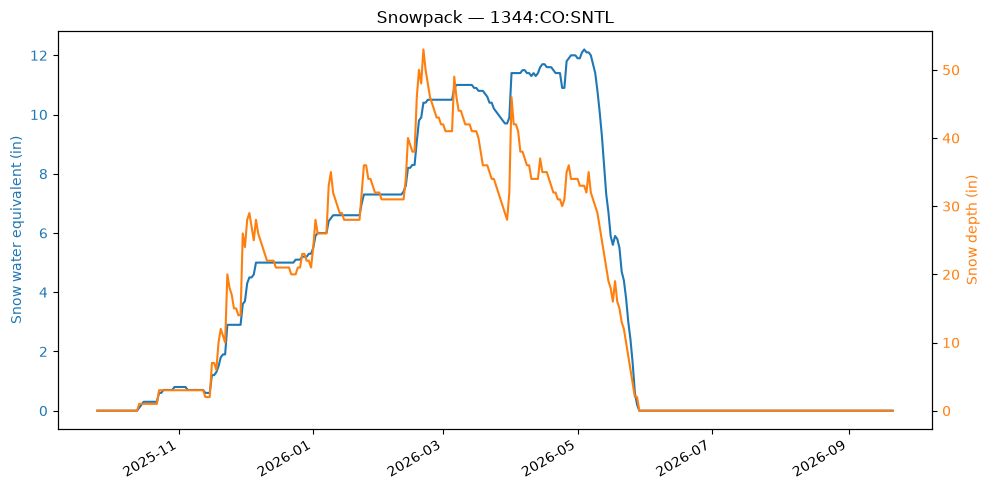

In [25]:
if swe_df.empty:
    print(f"No data returned for {example_triplet} in this date range.")
else:
    pivot = swe_df.pivot(index="date", columns="element", values="value")

    fig, ax1 = plt.subplots(figsize=(10, 5))

    if "WTEQ" in pivot.columns:
        ax1.plot(pivot.index, pivot["WTEQ"], color="tab:blue", label="SWE (in)")
        ax1.set_ylabel("Snow water equivalent (in)", color="tab:blue")
        ax1.tick_params(axis="y", labelcolor="tab:blue")

    if "SNWD" in pivot.columns:
        ax2 = ax1.twinx()
        ax2.plot(pivot.index, pivot["SNWD"], color="tab:orange", label="Snow depth (in)")
        ax2.set_ylabel("Snow depth (in)", color="tab:orange")
        ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.title(f"Snowpack — {example_triplet}")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

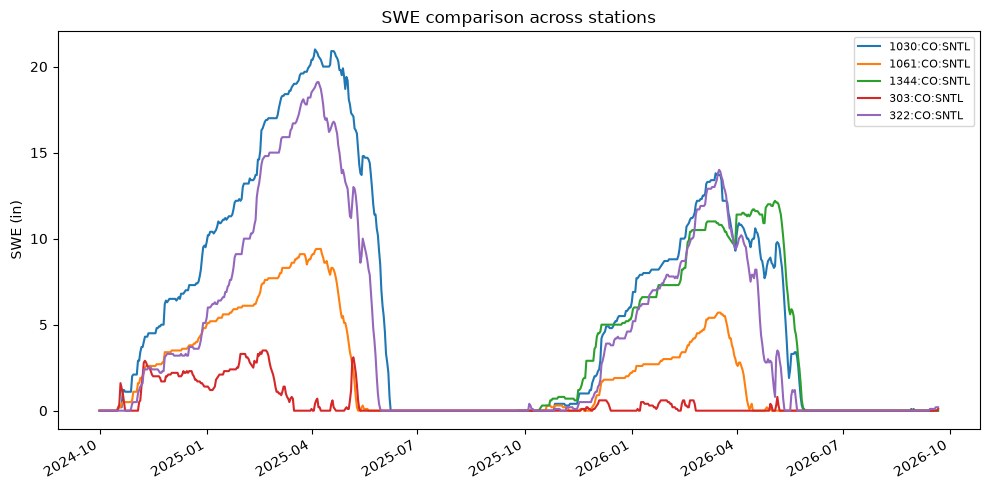

In [26]:
sample_triplets = co_stations["stationTriplet"].head(5).tolist() if len(co_stations) else [example_triplet]

multi_df = get_snowpack_data(
    station_triplets=sample_triplets,
    elements="WTEQ",
    begin_date="2024-10-01",
)

if multi_df.empty:
    print("No data returned for these stations/date range.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for triplet, group in multi_df.groupby("stationTriplet"):
        ax.plot(group["date"], group["value"], label=triplet)

    ax.set_ylabel("SWE (in)")
    ax.set_title("SWE comparison across stations")
    ax.legend(fontsize=8)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()